# BERT for Sentiment Analysis

In this notebook we fine-tune **BERT** for binary sentiment analysis on the **SST-2** dataset.

Three regimes are explored:
1. **Feature extraction** — freeze BERT, train only a linear classifier on `[CLS]` embeddings
2. **Full fine-tuning** — jointly update the classifier and all BERT weights
3. **Comparison** — visualise embeddings and analyse errors

**Requirements:**
```
pip install transformers datasets evaluate accelerate scikit-learn matplotlib
```

## 1 — Imports and configuration

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print(f'PyTorch version : {torch.__version__}')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device          : {device}')

PyTorch version : 2.7.0
Device          : mps


In [2]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import load_dataset
import evaluate

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 32
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## 2 — Load the SST-2 dataset

SST-2 is a binary sentiment dataset (positive / negative) from movie reviews, part of the GLUE benchmark.

In [3]:
raw_datasets = load_dataset('glue', 'sst2')
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [4]:
for i in range(3):
    ex = raw_datasets['train'][i]
    label_str = 'positive' if ex['label'] == 1 else 'negative'
    print(f"[{label_str}] {ex['sentence']}")
    print()

[negative] hide new secretions from the parental units 

[negative] contains no wit , only labored gags 

[positive] that loves its characters and communicates something rather beautiful about human nature 



Negative (0): 29,780   Positive (1): 37,569


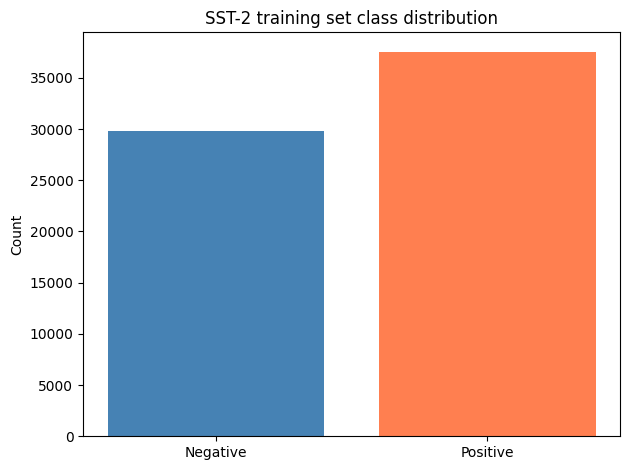

In [5]:
labels = raw_datasets['train']['label']
counts = Counter(labels)
print(f"Negative (0): {counts[0]:,}   Positive (1): {counts[1]:,}")

plt.bar(['Negative', 'Positive'], [counts[0], counts[1]], color=['steelblue', 'coral'])
plt.title('SST-2 training set class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3 — Tokenisation

BERT uses WordPiece tokenisation. Every sequence is wrapped with `[CLS]` at the start and `[SEP]` at the end.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = 'This film was absolutely fantastic!'
tokens  = tokenizer.tokenize(example)
encoded = tokenizer(example, return_tensors='pt')

print('Tokens :', tokens)
print('Input IDs:', encoded['input_ids'])
print('Decoded :', tokenizer.decode(encoded['input_ids'][0]))

Tokens : ['this', 'film', 'was', 'absolutely', 'fantastic', '!']
Input IDs: tensor([[  101,  2023,  2143,  2001,  7078, 10392,   999,   102]])
Decoded : [CLS] this film was absolutely fantastic! [SEP]


In [7]:
def tokenize_function(batch):
    return tokenizer(
        batch['sentence'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
    )

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Tokenisation done. Columns:', tokenized_datasets['train'].column_names)

Tokenisation done. Columns: ['sentence', 'labels', 'idx', 'input_ids', 'token_type_ids', 'attention_mask']


## 4 — Regime 1: Feature extraction (frozen BERT)

Extract `[CLS]` embeddings without updating BERT, then train logistic regression on top.

In [8]:
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

bert_encoder = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_encoder.eval()

def extract_cls_embeddings(model, dataset, batch_size=64, max_samples=None):
    """Return (embeddings, labels) numpy arrays."""
    subset = dataset.select(range(max_samples)) if max_samples else dataset
    loader = DataLoader(subset, batch_size=batch_size)
    all_emb, all_lbl = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            cls  = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_emb.append(cls)
            all_lbl.append(batch['labels'].numpy())
    return np.concatenate(all_emb), np.concatenate(all_lbl)

print('Extracting training embeddings...')
X_train, y_train = extract_cls_embeddings(bert_encoder, tokenized_datasets['train'], max_samples=5000)
print('Extracting validation embeddings...')
X_val, y_val = extract_cls_embeddings(bert_encoder, tokenized_datasets['validation'])

print(f'X_train shape: {X_train.shape},  X_val shape: {X_val.shape}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting training embeddings...


Extracting validation embeddings...


X_train shape: (5000, 768),  X_val shape: (872, 768)


In [9]:
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, y_train)

val_preds  = clf.predict(X_val)
acc_frozen = accuracy_score(y_val, val_preds)
print(f'Validation accuracy (frozen BERT + LR): {acc_frozen:.4f}')

/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/l

Validation accuracy (frozen BERT + LR): 0.8349


/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 5 — Regime 2: Full fine-tuning

Train BERT + classification head jointly using the HuggingFace `Trainer` API.

In [10]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [11]:
model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(device)

training_args = TrainingArguments(
    output_dir='./bert_sst2_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    seed=SEED,
    report_to='none',
)

TRAIN_SUBSET = 5000  # set to None to use the full training set

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=tokenized_datasets['train'].select(range(TRAIN_SUBSET)),
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics,
)

# Remove the NotebookProgressCallback that conflicts with nbconvert execution
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.pop_callback(NotebookProgressCallback)
except Exception:
    pass

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.output.LayerNor

TrainOutput(global_step=471, training_loss=0.253297712645966, metrics={'train_runtime': 449.9661, 'train_samples_per_second': 33.336, 'train_steps_per_second': 1.047, 'total_flos': 986666457600000.0, 'train_loss': 0.253297712645966, 'epoch': 3.0})

In [12]:
results_ft = trainer.evaluate()
acc_ft     = results_ft['eval_accuracy']
print(f'Validation accuracy (fine-tuned BERT):  {acc_ft:.4f}')
print(f'Improvement over frozen BERT:           +{acc_ft - acc_frozen:.4f}')

/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Validation accuracy (fine-tuned BERT):  0.9060
Improvement over frozen BERT:           +0.0711


## 6 — Visualise CLS embeddings with PCA

Project 768-dimensional `[CLS]` embeddings to 2D and compare **before** and **after** fine-tuning.

Extracting fine-tuned validation embeddings...


/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Use

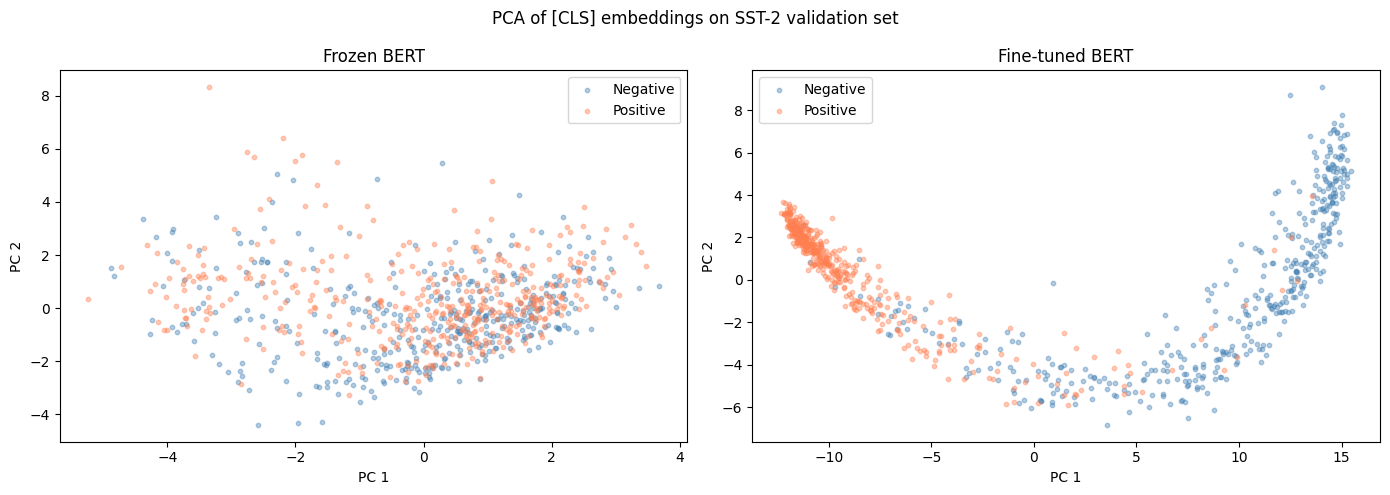

In [13]:
from sklearn.decomposition import PCA

ft_encoder = model_ft.bert.to(device)
ft_encoder.eval()

print('Extracting fine-tuned validation embeddings...')
X_val_ft, y_val_ft = extract_cls_embeddings(ft_encoder, tokenized_datasets['validation'])

Z_frozen = PCA(n_components=2, random_state=SEED).fit_transform(X_val)
Z_ft     = PCA(n_components=2, random_state=SEED).fit_transform(X_val_ft)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, y, title in zip(
    axes,
    [Z_frozen, Z_ft],
    [y_val, y_val_ft],
    ['Frozen BERT', 'Fine-tuned BERT'],
):
    for label, color, name in [(0, 'steelblue', 'Negative'), (1, 'coral', 'Positive')]:
        mask = (y == label)
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=name, alpha=0.4, s=10)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
plt.suptitle('PCA of [CLS] embeddings on SST-2 validation set')
plt.tight_layout()
plt.show()

## 7 — Error analysis

Examine the sentences the fine-tuned model gets wrong.

In [14]:
predictions = trainer.predict(tokenized_datasets['validation'])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

val_sentences = raw_datasets['validation']['sentence']
errors = [
    {'sentence': val_sentences[i], 'true': int(true_labels[i]), 'pred': int(pred_labels[i])}
    for i in range(len(true_labels))
    if true_labels[i] != pred_labels[i]
]

label_name = {0: 'negative', 1: 'positive'}
print(f'Misclassified: {len(errors)} / {len(true_labels)} ({100*len(errors)/len(true_labels):.1f}%)')
print()
for err in errors[:10]:
    t = label_name[err['true']]
    p = label_name[err['pred']]
    print(f'  True: {t:<10}  Pred: {p}')
    print(f'  {repr(err["sentence"])}')
    print()

/Users/cambroise/.pyenv/versions/3.11.8/envs/machine-learning/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Misclassified: 82 / 872 (9.4%)

  True: negative    Pred: positive
  'pumpkin takes an admirable look at the hypocrisy of political correctness , but it does so with such an uneven tone that you never know when humor ends and tragedy begins . '

  True: negative    Pred: positive
  'holden caulfield did it better . '

  True: negative    Pred: positive
  'a synthesis of cliches and absurdities that seems positively decadent in its cinematic flash and emptiness . '

  True: negative    Pred: positive
  'it feels like an after-school special gussied up with some fancy special effects , and watching its rote plot points connect is about as exciting as gazing at an egg timer for 93 minutes . '

  True: negative    Pred: positive
  'manages to be both repulsively sadistic and mundane . '

  True: negative    Pred: positive
  "the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow . "

  True: positive    Pred: negative
  "though it 's become almost redundan

## 8 — Inference on custom sentences

Use the fine-tuned model to predict sentiment on new sentences.

In [15]:
from transformers import pipeline

sentiment_pipe = pipeline(
    'sentiment-analysis',
    model=model_ft,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

custom_sentences = [
    'The acting was superb and the story deeply moving.',
    'A dull, predictable waste of two hours.',
    'Not bad, but not particularly memorable either.',
    'One of the best films I have seen this year!',
    'The plot made no sense whatsoever.',
]

results = sentiment_pipe(custom_sentences)
for sentence, result in zip(custom_sentences, results):
    print(f"[{result['label']}  {result['score']:.3f}]  {sentence}")

[LABEL_1  0.992]  The acting was superb and the story deeply moving.
[LABEL_0  0.984]  A dull, predictable waste of two hours.
[LABEL_0  0.951]  Not bad, but not particularly memorable either.
[LABEL_1  0.990]  One of the best films I have seen this year!
[LABEL_0  0.980]  The plot made no sense whatsoever.


## 9 — Optional: attention visualisation

BERT returns attention weights for each of its 144 heads (12 layers × 12 heads). We inspect which tokens the model focuses on.

In [16]:
from transformers import BertModel

sentence = 'The film was surprisingly good despite a weak script.'
inputs   = tokenizer(sentence, return_tensors='pt').to(device)

# attn_implementation must be set at model creation, not forward time.
# We create a fresh BertModel with 'eager' attention and copy fine-tuned weights.
bert_eager = BertModel.from_pretrained(
    MODEL_NAME, attn_implementation='eager'
).to(device)
bert_eager.load_state_dict(model_ft.bert.state_dict())
bert_eager.eval()

with torch.no_grad():
    outputs = bert_eager(**inputs, output_attentions=True)

tokens   = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
n_layers = len(outputs.attentions)
print(f'Sequence length: {len(tokens)},  Layers: {n_layers},  '
      f'Heads per layer: {outputs.attentions[0].shape[1]}')
print('Tokens:', tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sequence length: 12,  Layers: 12,  Heads per layer: 12
Tokens: ['[CLS]', 'the', 'film', 'was', 'surprisingly', 'good', 'despite', 'a', 'weak', 'script', '.', '[SEP]']


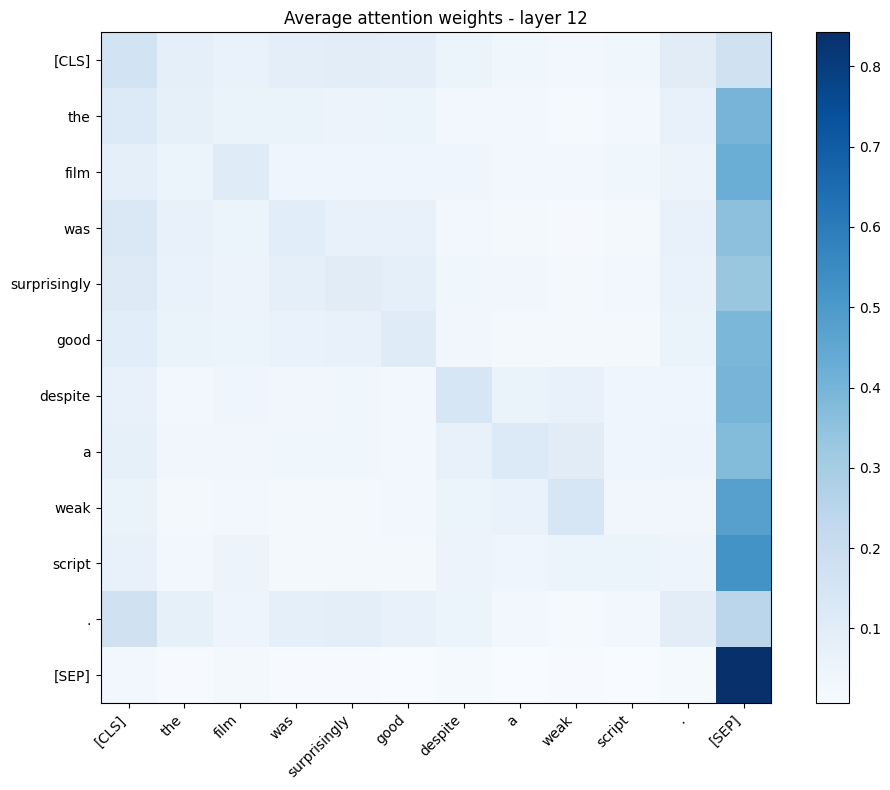

In [17]:
layer_idx = 11  # last layer
attn = outputs.attentions[layer_idx][0].mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attn, cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
plt.colorbar(im, ax=ax)
ax.set_title(f'Average attention weights - layer {layer_idx + 1}')
plt.tight_layout()
plt.show()